## Setup and imports

In [1]:
EXP_NAME = "SPS_audit_50_with_ind"

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [3]:
print(PROJECT_ROOT)

../..


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

sps_audit = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit.csv')
sbs_audit_baseline = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit_baseline.csv')
dataset = pd.read_csv(f'{PROJECT_ROOT}/data/heart_disease_cleaned.csv')

In [ ]:
# sps_audit.head()

# Analysis

### Basics

In [6]:
scorings = sps_audit.groupby('feature')[['sensitivity_scoring', 'fidelity_scoring']].first()

sps_audit = sps_audit.drop(['sensitivity_scoring', 'fidelity_scoring'], axis=1)

In [7]:
iteration_per_feature = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby('feature')[['roc_auc']].count()
iteration_per_feature

,roc_auc
feature,
age,26
ang,28
bp,23
chol,21
cp,26
ecg,25
mhr,21
slope,22
st,30


### Counterfactual sensitivity

In [8]:
sps_audit.groupby('feature')['cf_sensitivity'].agg(['mean','std','median']).sort_values(by='mean')

,mean,std,median
feature,,,
slope,0.072849,0.074146,0.053571
age,0.077156,0.028459,0.069531
ecg,0.095000,0.040682,0.089286
bp,0.146669,0.042455,0.142660
st,0.161410,0.045975,0.159889
mhr,0.187667,0.048926,0.188619
ang,0.275989,0.109488,0.256696
chol,0.276309,0.054831,0.276019
cp,0.379293,0.136584,0.350446


[]

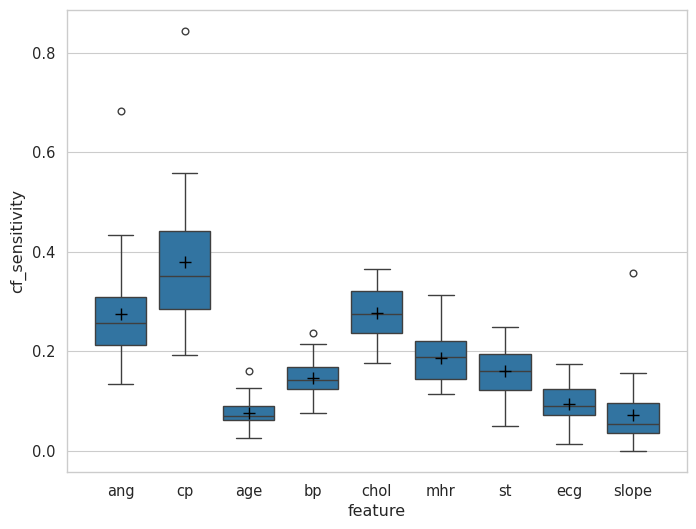

In [9]:
# Counterfactual sensitivity
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sps_audit, x="feature", y="cf_sensitivity", showmeans=True, 
            meanprops={"marker": "+",
                       "markeredgecolor": "black",
                       "markersize": "8"}, ax=ax)

plt.plot()


# Trade-off analyses

In [10]:
feature_desc_stats = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby(['feature'])[['ieco_mace', 'auprc', 'roc_auc', 'te_error']].median()
feature_corr_stats = sps_audit[sps_audit['bucket'] == 'x_corr'].groupby(['feature'])[['ieco_mace', 'auprc', 'roc_auc', 'te_error']].median()

In [11]:
baseline_te_error = sbs_audit_baseline['te_error'].values[0]
baseline_ieco_mace = sbs_audit_baseline['ieco_mace'].values[0]
baseline_roc_auc = sbs_audit_baseline['roc_auc'].values[0]
baseline_auprc = sbs_audit_baseline['auprc'].values[0]

## Total Effect estimation vs Fairness trade-off

In [12]:
print(f"Baseline TE error: {baseline_te_error}")
print(f"Baseline IECO MACE: {baseline_ieco_mace}")

Baseline TE error: 0.043815613
Baseline IECO MACE: 0.10923365


In [13]:
te_error_vs_fairness = sps_audit.groupby('iteration')[['te_error','ieco_mace', 'auprc']].first().sort_values('ieco_mace')
x_desc_configs = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby('iteration')['feature'].apply(list).to_dict()

pareto_frontier = []
current_min_te_error = 1

print('--- Configurations on the TE error Pareto Frontier ---')
for idx, solution in te_error_vs_fairness.iterrows():
  if solution['te_error'] < current_min_te_error:
    pareto_frontier.append(solution)
    current_min_te_error = solution['te_error']
    print(f'Iteration {idx}, Xdesc: {x_desc_configs[idx]}')
pareto_frontier_df = pd.DataFrame(pareto_frontier)
print(pareto_frontier_df.to_markdown())


--- Configurations on the TE error Pareto Frontier ---
Iteration 41, Xdesc: ['ang', 'age', 'bp']
Iteration 9, Xdesc: ['ang', 'age', 'bp', 'chol', 'mhr', 'slope']
Iteration 26, Xdesc: ['ang', 'cp', 'age', 'bp', 'chol', 'mhr', 'st', 'ecg']
Iteration 13, Xdesc: ['ang', 'cp', 'st', 'ecg']
Iteration 29, Xdesc: ['ang', 'chol', 'ecg', 'slope']
|    |   te_error |   ieco_mace |    auprc |
|---:|-----------:|------------:|---------:|
| 41 |  0.0769346 |   0.0728608 | 0.913798 |
|  9 |  0.0567462 |   0.0803168 | 0.914487 |
| 26 |  0.0424277 |   0.0885085 | 0.921297 |
| 13 |  0.0392025 |   0.0953358 | 0.91236  |
| 29 |  0.0113297 |   0.127193  | 0.90788  |


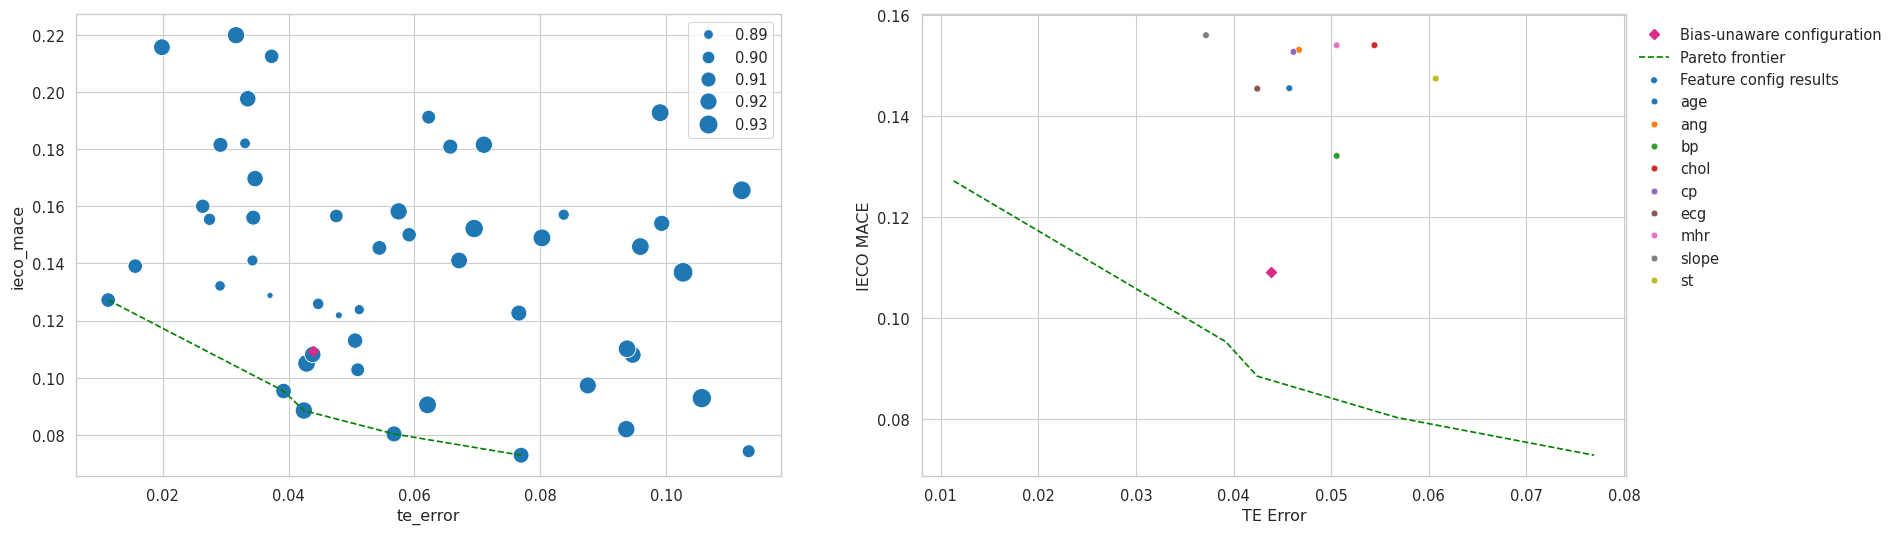

In [14]:


fig, axes = plt.subplots(1, 2,  figsize=(20, 6))
axes[0].plot(baseline_te_error, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
axes[1].plot(baseline_te_error, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
sns.scatterplot(data=te_error_vs_fairness, x='te_error', y='ieco_mace', size="auprc", sizes=(20, 200) ,ax=axes[0])
axes[0].legend_.set_title('AUPRC')
sns.lineplot(data=pareto_frontier_df, x='te_error', y='ieco_mace', color="green", marker='', linestyle="--", errorbar=None, ax=axes[0])
sns.lineplot(data=pareto_frontier_df, x='te_error', y='ieco_mace', color="green", linestyle="--", errorbar=None, ax=axes[1])
sns.scatterplot(data=feature_desc_stats, x='te_error', y='ieco_mace', hue='feature', color='', ax=axes[1])
# plt.axvline(auprc_baseline)
plt.xlabel('TE Error')
plt.ylabel('IECO MACE')
plt.legend(labels=[ 
                   'Bias-unaware configuration',
                   'Pareto frontier', 
                   "Feature config results",
                   ]+feature_desc_stats.index.to_list(),
           loc='upper left', bbox_to_anchor=(1, 1), edgecolor="white")

plt.show()

# Utility vs Fairness trade-off

In [15]:
print(f"Baseline Average Precision: {baseline_auprc}")
print(f"Baseline ROC AUC: {baseline_roc_auc}")
print(f"Baseline IECO MACE: {baseline_ieco_mace}")

Baseline Average Precision: 0.9216251066586548
Baseline ROC AUC: 0.9337806534068216
Baseline IECO MACE: 0.10923365


## Pareto Frontier 


--- Configurations on the AUPRC Pareto Frontier ---
Iteration 41, Xdesc: ['ang', 'age', 'bp']
Iteration 9, Xdesc: ['ang', 'age', 'bp', 'chol', 'mhr', 'slope']
Iteration 31, Xdesc: ['cp', 'age', 'bp', 'chol', 'mhr', 'st', 'ecg']
Iteration 26, Xdesc: ['ang', 'cp', 'age', 'bp', 'chol', 'mhr', 'st', 'ecg']
Iteration 11, Xdesc: ['ecg']
Iteration 28, Xdesc: ['mhr', 'ecg']
Iteration 0, Xdesc: ['bp']
|    |   roc_auc |    auprc |   ieco_mace |   te_error |
|---:|----------:|---------:|------------:|-----------:|
| 41 |  0.929307 | 0.913798 |   0.0728608 |  0.0769346 |
|  9 |  0.913012 | 0.914487 |   0.0803168 |  0.0567462 |
| 31 |  0.924754 | 0.921223 |   0.0819813 |  0.0936594 |
| 26 |  0.925234 | 0.921297 |   0.0885085 |  0.0424277 |
| 11 |  0.930665 | 0.923314 |   0.0904965 |  0.0620751 |
| 28 |  0.939212 | 0.932156 |   0.0928517 |  0.10566   |
|  0 |  0.939851 | 0.934146 |   0.136905  |  0.102677  |


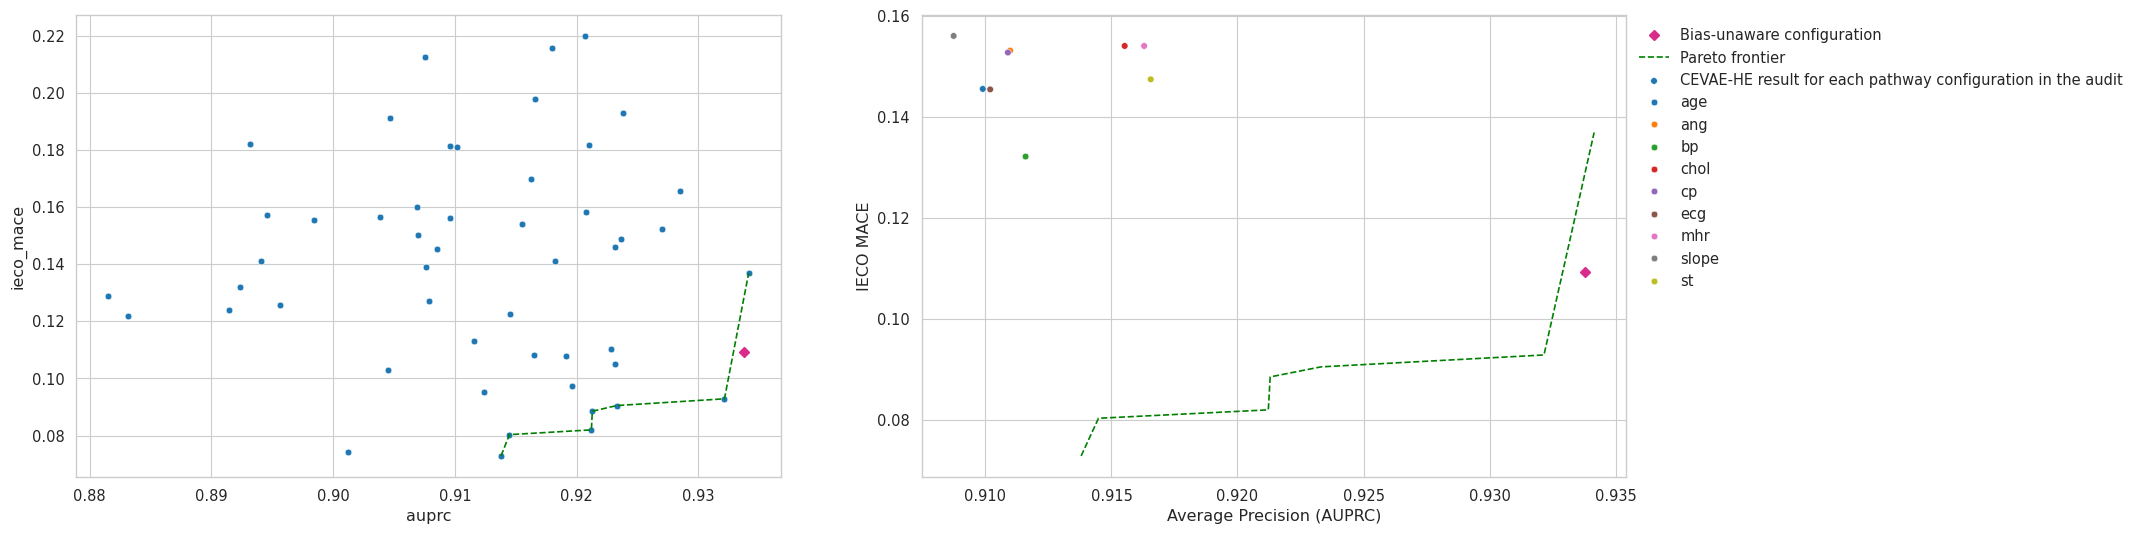

In [16]:
utility_vs_fairness = sps_audit.groupby('iteration')[['roc_auc', 'auprc','ieco_mace', 'te_error']].first().sort_values('ieco_mace')
x_desc_configs = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby('iteration')['feature'].apply(list).to_dict()

positives = dataset[dataset['cvd'] == 1]
auprc_baseline = len(positives) / len(dataset)

pareto_frontier = []
current_max_utility = -1

print('--- Configurations on the AUPRC Pareto Frontier ---')
for idx, solution in utility_vs_fairness.iterrows():
  if solution['auprc'] > current_max_utility:
    pareto_frontier.append(solution)
    current_max_utility = solution['auprc']
    print(f'Iteration {idx}, Xdesc: {x_desc_configs[idx]}')
pareto_frontier_df = pd.DataFrame(pareto_frontier)
print(pareto_frontier_df.to_markdown())


fig, axes = plt.subplots(1, 2,  figsize=(20, 6))
axes[0].plot(baseline_roc_auc, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
axes[1].plot(baseline_roc_auc, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
sns.lineplot(data=pareto_frontier_df, x='auprc', y='ieco_mace', color="green", marker='', linestyle="--", errorbar=None, ax=axes[0])
sns.lineplot(data=pareto_frontier_df, x='auprc', y='ieco_mace', color="green", linestyle="--", errorbar=None, ax=axes[1])
sns.scatterplot(data=utility_vs_fairness, x='auprc', y='ieco_mace', ax=axes[0])
sns.scatterplot(data=feature_desc_stats, x='auprc', y='ieco_mace', hue='feature', color='', ax=axes[1])
# plt.axvline(auprc_baseline)
plt.xlabel('Average Precision (AUPRC)')
plt.ylabel('IECO MACE')
plt.legend(labels=[ 
                   'Bias-unaware configuration',
                   'Pareto frontier', 
                   'CEVAE-HE result for each pathway configuration in the audit'
                   ]+feature_desc_stats.index.to_list(),
           loc='upper left', bbox_to_anchor=(1, 1), edgecolor="white")

plt.show()

In [17]:
feature_desc_stats['ieco_baseline_delta'] = feature_desc_stats['ieco_mace'] - baseline_ieco_mace
feature_desc_stats['auprc_baseline_delta'] = feature_desc_stats['auprc'] - baseline_roc_auc
feature_desc_stats['roc_auc_baseline_delta'] = feature_desc_stats['roc_auc'] - baseline_roc_auc 
feature_desc_stats['ieco_corr_delta'] = feature_desc_stats['ieco_mace'] - feature_corr_stats['ieco_mace']
feature_desc_stats['auprc_corr_delta'] = feature_desc_stats['auprc'] - feature_corr_stats['auprc']
feature_desc_stats['roc_auc_corr_delta'] = feature_desc_stats['roc_auc'] - feature_corr_stats['roc_auc']

feature_desc_stats = feature_desc_stats.sort_values('ieco_baseline_delta')
print(feature_desc_stats.to_markdown())

| feature   |   ieco_mace |    auprc |   roc_auc |   te_error |   ieco_baseline_delta |   auprc_baseline_delta |   roc_auc_baseline_delta |   ieco_corr_delta |   auprc_corr_delta |   roc_auc_corr_delta |
|:----------|------------:|---------:|----------:|-----------:|----------------------:|-----------------------:|-------------------------:|------------------:|-------------------:|---------------------:|
| bp        |    0.132143 | 0.911594 |  0.919722 |  0.0505623 |             0.0229096 |             -0.0221862 |               -0.0140586 |       -0.0168154  |        -0.00470227 |         -0.00631041  |
| ecg       |    0.145446 | 0.910191 |  0.919722 |  0.0424277 |             0.0362125 |             -0.0235897 |               -0.0140586 |        0.00440653 |        -0.00629739 |         -0.00694944  |
| age       |    0.14554  | 0.909898 |  0.915289 |  0.0457082 |             0.0363061 |             -0.0238827 |               -0.0184919 |        0.00548661 |        -0.0100089  |    

[]

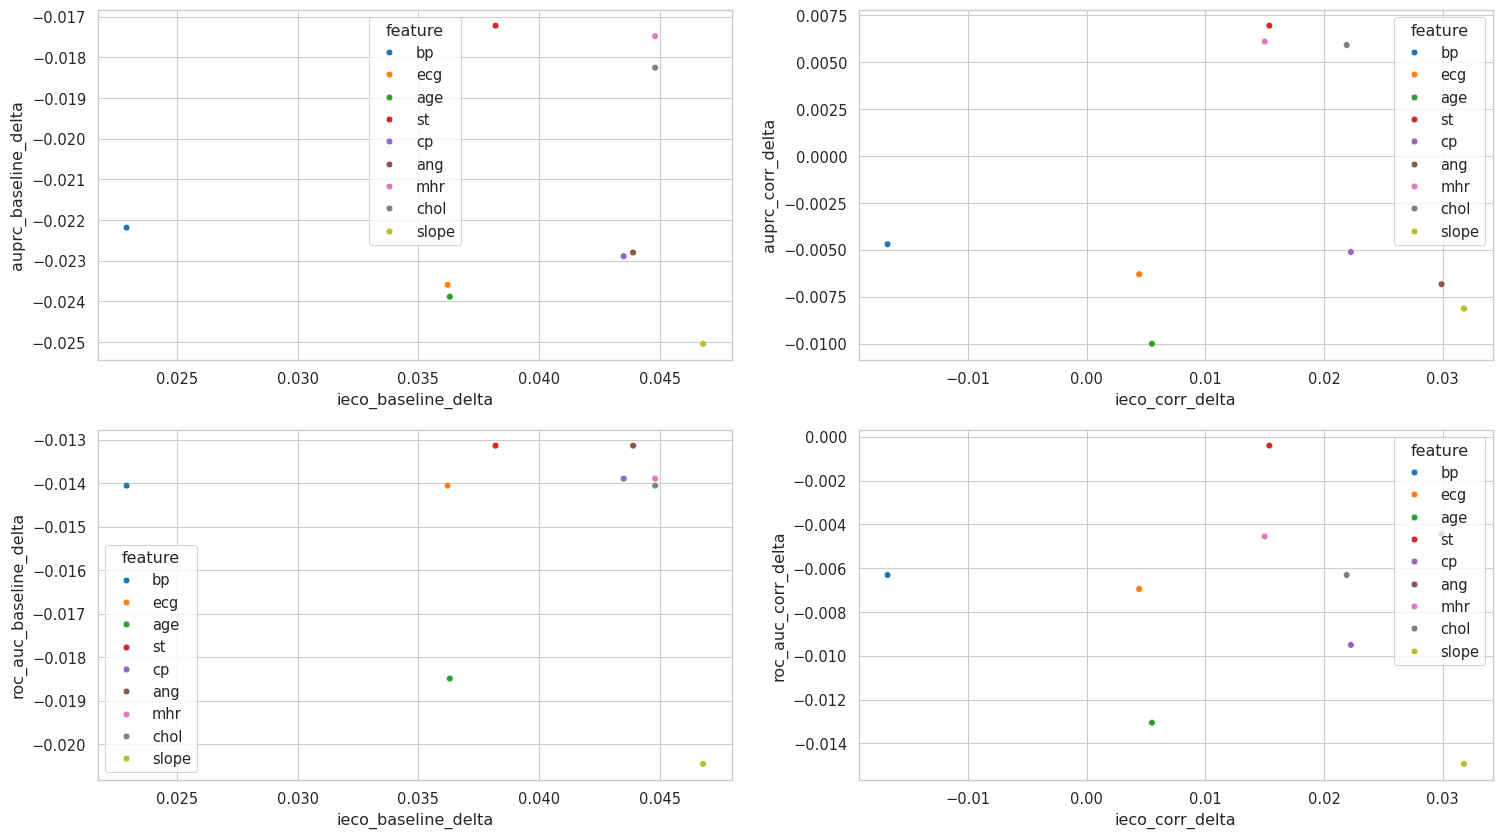

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.scatterplot(data=feature_desc_stats, x='ieco_baseline_delta', y='auprc_baseline_delta', hue='feature', ax=axes[0,0])
sns.scatterplot(data=feature_desc_stats, x='ieco_baseline_delta', y='roc_auc_baseline_delta', hue='feature', ax=axes[1,0])
sns.scatterplot(data=feature_desc_stats, x='ieco_corr_delta', y='auprc_corr_delta', hue='feature', ax=axes[0,1])
sns.scatterplot(data=feature_desc_stats, x='ieco_corr_delta', y='roc_auc_corr_delta', hue='feature', ax=axes[1,1])
plt.plot()